# KNN classifier
>breast_cancer.csv

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [7]:
df = pd.read_csv('breast_cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [8]:
# dropping redundant columns
df = df.drop(columns=['id','Unnamed: 32'])

In [11]:
print(df.columns)

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [15]:
# features and target
x = df.iloc[:,1:-1]
y = df.iloc[:, 0]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [16]:
# scaling the dataset (x)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

> **for K = 5**

In [23]:
# model train
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train, y_train)

y_Pred = knn.predict(x_test)

In [24]:
# accuracy
print('accuracy_score: ',accuracy_score(y_test, y_Pred))

accuracy_score:  0.956140350877193


> **Trying different values of K**

In [20]:
accuracy_list = []

for i in range(1,16):
    KNN = KNeighborsClassifier(n_neighbors=i)
    KNN.fit(x_train,y_train)
    y_pred = KNN.predict(x_test)
    accuracy_list.append(accuracy_score(y_test, y_pred))

accuracy_list

[0.9385964912280702,
 0.9473684210526315,
 0.9473684210526315,
 0.9385964912280702,
 0.9473684210526315,
 0.9473684210526315,
 0.9473684210526315,
 0.9385964912280702,
 0.9473684210526315,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193]

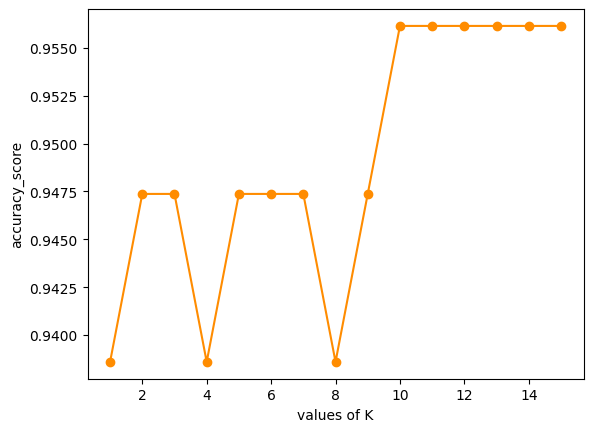

In [22]:
# plot of accuracies
plt.plot(range(1,16), accuracy_list, color = 'darkorange', marker = 'o')
plt.xlabel('values of K')
plt.ylabel('accuracy_score')
plt.show()

> **✅ MAX accuracy is at K = 10**

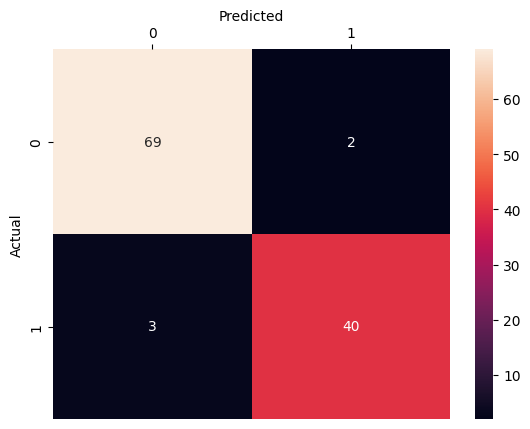

In [29]:
# confusion matrix
sns.heatmap(confusion_matrix(y_test, y_Pred), annot = True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.gca().xaxis.set_label_position("top")
plt.gca().xaxis.tick_top()
plt.show()

> **Decision boundry** 👇

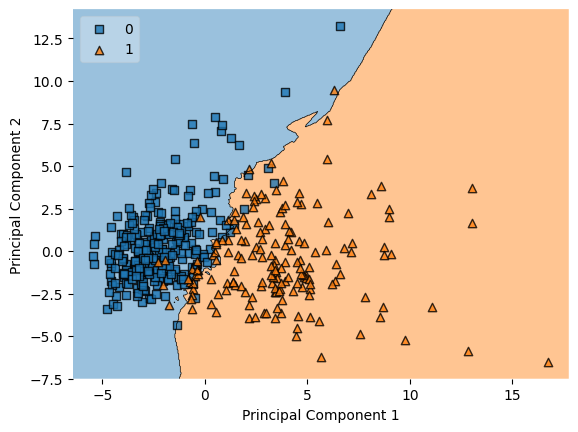

In [36]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Scale
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

# Split
x_train, x_test, y_train, y_test = train_test_split(
    x_pca, y, test_size=0.2, random_state=42
)

# Train
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train, y_train)

# Plot
plot_decision_regions(x_train, y_train, clf=knn, legend=2)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()